# 2. Autonomous Drone Rescue Using Dynamic Programming

## 1. Custom Drone Rescue Environment

The problem is about a rescue drone that needs to fly around a disaster zone and rescue targets(stranded civilians). The environment is set up as a 6x6 grid world. The drone starts at the top-left with 10 units of battery and it has to figure out the best way to reach all 3 rescue targets without running out of power or stepping into danger zones.

We are implementing a reinforcement learning agent to compute the optimal policy for this finite Markov Decision Process problem using Dynamic Programming (value iteration specifically).

### My Grid Design

We designed the gird with a particular instinct that the rescue targets are spread out so the drone cant just rush to all of them in one go — it actually needs to plan around the chargers and avoid the danger cells. Since we are group 78 we chose the grid as follows:

- 3 rescue targets at (1,4), (3,5), (5,1)
- 2 charging stations at (3,0) and (5,3) - Since we have a limited steps
- 4 danger zones, 3 blocked cells, 3 wind zones (choose 3 wind zones around blocked/danger and one rescue target to create randomness)
- Starting battery = 10 (max capacity)

The actual grid looks as below

         Col0  Col1  Col2  Col3  Col4  Col5
    Row0:  S     F     F     D     F     F
    Row1:  F     X     W     F     R     F
    Row2:  F     F     D     F     F     W
    Row3:  C     F     F     X     F     R
    Row4:  F     F     D     F     W     F
    Row5:  D     R     F     C     X     F

Symbols: S=Start, F=Free, D=Danger, R=Rescue target, C=Charger, W=Wind, X=Blocked

### State Space

Represented each state as a tuple: (row, col, battery, rescued_status, steps)

- row, col: position (0 to 5)
- battery: 0 to 10
- rescued_status: tuple of 3 binary flags, like (1,0,1) means targets 1 and 3 are rescued
- steps(step_count): 0 to 75

Upper bound on states = 6×6×11×8×76 = 240768 (many of those are unreachable)

### Actions

5 possible actions — Up(0), Down(1), Left(2), Right(3), Hover(4). All of them cost 1 battery. If the drone tries to move off the grid or into a blocked cell (X), it stays put but still burns battery.

Special case: hovering on a charger gives +2 battery (maximum battery 10). Since hovering also costs 1, the gain is +1 per turn.

### Rewards
- Rescue target reached: +20
- Enter charger: +5 (and full recharge)
- Enter danger zone: -10
- Battery hits 0: -20
- Every action: -1 (base cost)

### Wind Zones

If the drone is on a W cell and tries to move, theres a 30% chance the wind changes its direction randomly. The random direction is picked uniformly from all 4 movement directions. So the intended action happens with probability 0.7 + 0.3/4 = 0.775 and each other direction has 0.075 probability. Hover is not affected.

For example:

    Current cell    Action  Transition Probability
    Non-Wind        Right   Right = 1.0
    Wind            Right   Right = 0.7
    Wind            Right   Up = 0.075
    Wind            Right   Down = 0.075
    Wind            Right   Left = 0.075
    Wind            Right   Right (wind-selected) = 0.075


### Episode End Conditions
- Battery = 0 → terminated (with -20 penalty)
- All 3 targets rescued → terminated (success)
- 75 steps reached → truncated

In [39]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import random
import time
import matplotlib.pyplot as plt

In [40]:
class DroneRescueEnv(gym.Env):
    """6x6 grid world for the drone rescue problem. Implements gymnasium interface."""

    def __init__(self):
        #Initialize the environment
        super().__init__()

        self.grid_size = 6
        self.max_battery = 10
        self.max_steps = 75
        self.wind_prob = 0.3

        self.action_space = spaces.Discrete(5)  # up, down, left, right, hover
        self.observation_space = spaces.Tuple((
            spaces.Discrete(self.grid_size),
            spaces.Discrete(self.grid_size),
            spaces.Discrete(self.max_battery + 1),
            spaces.MultiBinary(3)
        ))

        # grid layout - S=start, F=free, D=danger, R=rescue, C=charger, W=wind, X=blocked
        self.grid = np.array([
            ['S', 'F', 'F', 'D', 'F', 'F'],
            ['F', 'X', 'W', 'F', 'R', 'F'],
            ['F', 'F', 'D', 'F', 'F', 'W'],
            ['C', 'F', 'F', 'X', 'F', 'R'],
            ['F', 'F', 'D', 'F', 'W', 'F'],
            ['D', 'R', 'F', 'C', 'X', 'F']
        ])

        self.rescue_targets = [(1, 4), (3, 5), (5, 1)]
        self.start_pos = (0, 0)
        self.initial_grid = self.grid.copy()
        self.reset()

    def reset(self, seed=None, options=None):
        #Resets the environment to initial state, returns initial observation and info.
        super().reset(seed=seed)
        self.grid = self.initial_grid.copy()
        self.pos = self.start_pos
        self.battery = self.max_battery
        self.rescued = [0, 0, 0]
        self.steps = 0
        return (self.pos[0], self.pos[1], self.battery, np.array(self.rescued)), {}

    def get_valid_actions(self, state):
        #Returns valid actions from a state. Empty list if terminal.
        _, _, battery, rescued = state
        if battery <= 0 or all(rescued):
            return []
        return [0, 1, 2, 3, 4]

    def render(self):
        # prints the grid to console with drone position marked as 'P'
        for r in range(self.grid_size):
            row_str = []
            for c in range(self.grid_size):
                if (r, c) == self.pos:
                    row_str.append('P')
                else:
                    row_str.append(self.grid[r, c])
            print(' '.join(row_str))
        print(f"Battery: {self.battery} | Rescued: {self.rescued} | Steps: {self.steps}")

    def step(self, action):
        #Take action, return (obs, reward, terminated, truncated, info)
        r, c = self.pos

        # wind effect on W cells - 30% chance of random direction
        if self.grid[r, c] == 'W' and action in [0, 1, 2, 3]:
            if random.random() < self.wind_prob:
                action = random.choice([0, 1, 2, 3])

        # compute new position
        nr, nc = r, c
        if action == 0 and r > 0:
            nr -= 1
        elif action == 1 and r < self.grid_size - 1:
            nr += 1
        elif action == 2 and c > 0:
            nc -= 1
        elif action == 3 and c < self.grid_size - 1:
            nc += 1
        # action 4 = hover, stay put

        # blocked cell check
        if self.grid[nr, nc] == 'X':
            nr, nc = r, c

        self.pos = (nr, nc)
        self.battery -= 1
        self.steps += 1

        reward = -1
        terminated = False
        truncated = False
        moved = (nr, nc) != (r, c)
        cell = self.grid[nr, nc]

        if cell == 'R':
            for idx, target in enumerate(self.rescue_targets):
                if (nr, nc) == target and self.rescued[idx] == 0:
                    reward += 20
                    self.rescued[idx] = 1
                    self.grid[nr, nc] = 'F'
                    break
        elif action == 4 and cell == 'C':
            # hover on charger: +2 battery (net +1 after the -1 cost)
            self.battery = min(self.battery + 2, self.max_battery)
        elif moved and cell == 'C':
            reward += 5
            self.battery = self.max_battery
        elif moved and cell == 'D':
            reward -= 10

        if self.battery <= 0:
            reward -= 20
            terminated = True
        if all(self.rescued):
            terminated = True
        if self.steps >= self.max_steps:
            truncated = True

        obs = (nr, nc, self.battery, np.array(self.rescued))
        return obs, reward, terminated, truncated, {}

## 2. Value Iteration

We are trying to solve for the optimal policy using value iteration instead of learning from episodes. We have to keep updating V(s) using the Bellman equation until the values converge:
        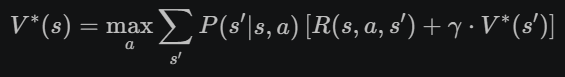

Set gamma=1.0 because the episode is finite (max 75 steps). The convergence threshold theta is 0.001.

The handling of the wind cells has to be done properly in the transition function — on a W cell, each movement action can result in 4 possible outcomes with different probabilities, so we have to compute all of them and weight by probability.

In [41]:
THETA = 1e-3
GAMMA = 1.0
ACTIONS = [0, 1, 2, 3, 4]
ACTION_NAMES = {0: 'Up', 1: 'Down', 2: 'Left', 3: 'Right', 4: 'Hover'}


def normalize_state(state):
    # need to convert rescued array to tuple so it can be used as dict key
    r, c, b, rescued, steps = state
    return (r, c, b, tuple(int(x) for x in rescued), int(steps))


def is_terminal(state, max_steps):
    #Check if state is terminal: battery <= 0, all rescued, or max steps reached
    _, _, battery, rescued, steps = state
    return battery <= 0 or all(rescued) or steps >= max_steps


def get_cell_type(env, r, c, rescued):
    # if this cell had a rescue target that's already been rescued, treat it as free
    for idx, (tr, tc) in enumerate(env.rescue_targets):
        if (r, c) == (tr, tc):
            return 'R' if rescued[idx] == 0 else 'F'
    return env.initial_grid[r, c]


def apply_move(env, r, c, action):
    # movement with boundary + blocked cell handling
    nr, nc = r, c
    if action == 0 and r > 0:
        nr -= 1
    elif action == 1 and r < env.grid_size - 1:
        nr += 1
    elif action == 2 and c > 0:
        nc -= 1
    elif action == 3 and c < env.grid_size - 1:
        nc += 1
    if env.initial_grid[nr, nc] == 'X':
        nr, nc = r, c
    return nr, nc


def get_action_probs(env, r, c, rescued, action):
    # on wind cells: 30% chance of random direction, 70% intended
    # hover is never affected by wind
    if get_cell_type(env, r, c, rescued) == 'W' and action in [0, 1, 2, 3]:
        probs = {a: env.wind_prob / 4 for a in [0, 1, 2, 3]}
        probs[action] += (1 - env.wind_prob)
        return probs
    return {action: 1.0}


def get_transitions(env, state, action):
    #Given (state, action), return all possible (prob, next_state, reward, done) outcomes.
    r, c, battery, rescued, steps = state
    outcomes = {}

    for actual_action, prob in get_action_probs(env, r, c, rescued, action).items():
        nr, nc = apply_move(env, r, c, actual_action)
        new_batt = battery - 1
        new_rescued = list(rescued)
        new_steps = steps + 1
        reward = -1
        moved = (nr, nc) != (r, c)

        cell = get_cell_type(env, nr, nc, rescued)

        if cell == 'R':
            for idx, target in enumerate(env.rescue_targets):
                if (nr, nc) == target and new_rescued[idx] == 0:
                    reward += 20
                    new_rescued[idx] = 1
                    break
        elif actual_action == 4 and env.initial_grid[r, c] == 'C':
            new_batt = min(new_batt + 2, env.max_battery)
        elif moved and env.initial_grid[nr, nc] == 'C':
            reward += 5
            new_batt = env.max_battery
        elif moved and env.initial_grid[nr, nc] == 'D':
            reward -= 10

        done = (new_batt <= 0) or all(new_rescued) or (new_steps >= env.max_steps)
        if new_batt <= 0:
            reward -= 20

        # aggregate same outcomes (wind can produce duplicates)
        ns = (nr, nc, new_batt, tuple(new_rescued), new_steps)
        key = (ns, reward, done)
        outcomes[key] = outcomes.get(key, 0) + prob

    return [(p, ns, rw, dn) for (ns, rw, dn), p in outcomes.items()]


def list_reachable_states(env, start):
    #BFS to find all reachable states from start.
    start = normalize_state(start)
    visited = {start}
    queue = [start]
    while queue:
        s = queue.pop()
        if is_terminal(s, env.max_steps):
            continue
        for a in ACTIONS:
            for _, ns, _, _ in get_transitions(env, s, a):
                if ns not in visited:
                    visited.add(ns)
                    queue.append(ns)
    return visited


def value_iteration(env, theta=THETA, gamma=GAMMA):
    start = normalize_state((0, 0, env.max_battery, (0, 0, 0), 0))

    # first enumerate all reachable states using BFS
    print("Finding reachable states...")
    all_states = list(list_reachable_states(env, start))
    idx_map = {s: i for i, s in enumerate(all_states)}
    n = len(all_states)
    is_term = np.array([is_terminal(s, env.max_steps) for s in all_states])
    print(f"Found {n} states. Precomputing transitions...")

    # precompute transition table for speed
    # trans[i][a] = [(prob, next_idx, reward, done), ...]
    trans = [[[] for _ in range(5)] for _ in range(n)]
    for i in range(n):
        if is_term[i]:
            for a in ACTIONS:
                trans[i][a] = [(1.0, i, 0.0, True)]
        else:
            for a in ACTIONS:
                trans[i][a] = [
                    (prob, idx_map[ns], rw, dn)
                    for prob, ns, rw, dn in get_transitions(env, all_states[i], a)
                ]

    # run bellman updates
    V = np.zeros(n)
    iters = 0
    non_term = np.where(~is_term)[0]

    t0 = time.time()
    print("Running value iteration...")

    while True:
        delta = 0.0
        for i in non_term:
            old_v = V[i]
            best = float('-inf')
            for a in ACTIONS:
                q = 0.0
                for prob, j, rew, done in trans[i][a]:
                    q += prob * (rew + (0.0 if done else gamma * V[j]))
                best = max(best, q)
            V[i] = best
            delta = max(delta, abs(best - old_v))
        iters += 1
        if delta < theta:
            break

    elapsed = time.time() - t0

    # extract policy
    V_dict = {all_states[i]: V[i] for i in range(n)}
    policy = {}
    for i in range(n):
        if is_term[i]:
            continue
        best_a, best_q = 0, float('-inf')
        for a in ACTIONS:
            q = sum(p * (r + (0.0 if d else gamma * V[j])) for p, j, r, d in trans[i][a])
            if q > best_q:
                best_q = q
                best_a = a
        policy[all_states[i]] = best_a

    return {
        'V': V_dict, 'policy': policy, 'states': set(all_states),
        'start_state': start, 'reachable_state_count': n,
        'iterations': iters, 'final_delta': delta, 'runtime_seconds': elapsed,
    }


# run it
env = DroneRescueEnv()
results = value_iteration(env)

print(f"\nDone! {results['reachable_state_count']} states, "
      f"{results['iterations']} iterations, "
      f"delta={results['final_delta']:.6f}, "
      f"took {results['runtime_seconds']:.1f}s")
print(f"V*(start) = {results['V'][results['start_state']]:.4f}")
print(f"Best first move: {ACTION_NAMES[results['policy'][results['start_state']]]}")

Finding reachable states...
Found 104020 states. Precomputing transitions...
Running value iteration...

Done! 104020 states, 45 iterations, delta=0.000000, took 10.4s
V*(start) = 141.8787
Best first move: Down


## 3. Policy Visualization

Four plots showing how the learned policy actually behaves:

1. **Movement Directions** — arrows at each grid cell showing the most common action the policy picks
2. **Rescue Sequence** — the full drone trajectory with rescue events numbered
3. **Charging Behaviour** — where the drone recharges along its path and how battery changes
4. **Danger Zone Avoidance** — how the trajectory routes around the dangerous cells

Drone successfully avoided ALL danger zones throughout the trajectory!


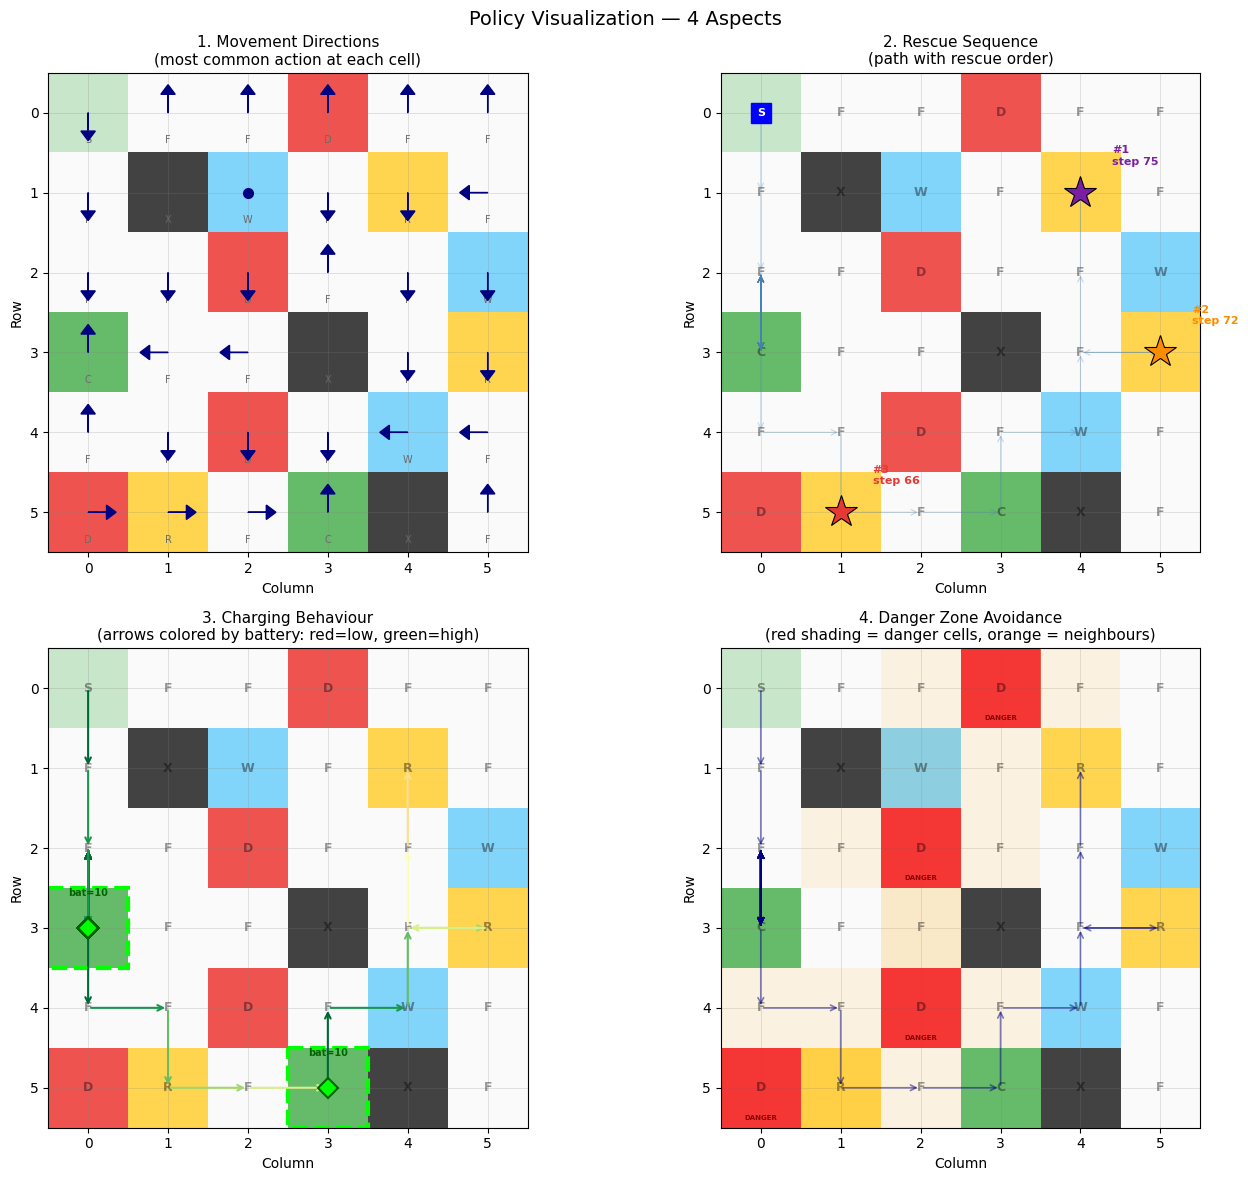


Trajectory: 75 steps, final battery: 3
All rescued: True

Rescue order:
  Target 3 at (5, 1) — step 66
  Target 2 at (3, 5) — step 72
  Target 1 at (1, 4) — step 75

Charger visits: 32 steps spent on charging stations


In [42]:
# cell type colors and arrow direction offsets
CELL_COLORS = {
    'S': '#C8E6C9', 'F': '#FAFAFA', 'D': '#EF5350', 'R': '#FFD54F',
    'C': '#66BB6A', 'W': '#81D4FA', 'X': '#424242',
}
ARROW_OFFSETS = {0: (0, -0.35), 1: (0, 0.35), 2: (-0.35, 0), 3: (0.35, 0), 4: (0, 0)}


def deterministic_step(env, state, action):
    #pick the highest-probability outcome (ignores wind randomness)
    trans = get_transitions(env, state, action)
    return max(trans, key=lambda t: t[0])[1]


def simulate_optimal_path(env, policy):
    #run the drone following the policy and record the path + rescue events
    state = normalize_state((0, 0, env.max_battery, (0, 0, 0), 0))
    path = [state]
    rescues = []
    prev_r = state[3]
    for _ in range(env.max_steps):
        if is_terminal(state, env.max_steps) or state not in policy:
            break
        state = deterministic_step(env, state, policy[state])
        path.append(state)
        for idx, tgt in enumerate(env.rescue_targets):
            if state[3][idx] == 1 and prev_r[idx] == 0:
                rescues.append((len(path)-1, tgt, idx+1))
        prev_r = state[3]
        if is_terminal(state, env.max_steps):
            break
    return path, rescues


def make_grid_img(env):
    #build a colored image of the grid based on cell types
    img = np.zeros((env.grid_size, env.grid_size, 3))
    for r in range(env.grid_size):
        for c in range(env.grid_size):
            hx = CELL_COLORS[env.initial_grid[r, c]]
            img[r, c] = [int(hx[i:i+2], 16)/255 for i in (1, 3, 5)]
    return img


def draw_grid_labels(ax, env):
    #put cell type letter on each cell
    for r in range(env.grid_size):
        for c in range(env.grid_size):
            ax.text(c, r, env.initial_grid[r, c], ha='center', va='center',
                    fontsize=9, fontweight='bold', color='black', alpha=0.4)


# --- simulate the path once, reuse in all plots ---
path, rescues = simulate_optimal_path(env, results['policy'])

fig, axes = plt.subplots(2, 2, figsize=(14, 12))


# ============ PLOT 1: Movement Directions ============
ax = axes[0, 0]
ax.imshow(make_grid_img(env), origin='upper')

# find most common action at each cell across all states
from collections import Counter
for r in range(env.grid_size):
    for c in range(env.grid_size):
        acts = [a for (rr, cc, b, rs, st), a in results['policy'].items()
                if rr == r and cc == c]
        if acts:
            best = Counter(acts).most_common(1)[0][0]
            dx, dy = ARROW_OFFSETS[best]
            if best == 4:
                ax.plot(c, r, 'o', color='navy', markersize=7, zorder=5)
            else:
                ax.arrow(c, r, dx, dy, head_width=0.18, head_length=0.12,
                         fc='navy', ec='navy', length_includes_head=True, zorder=5)
    # labels
    for c2 in range(env.grid_size):
        ax.text(c2, r+0.38, env.initial_grid[r, c2], ha='center', fontsize=7, color='dimgray')

ax.set_title('1. Movement Directions\n(most common action at each cell)', fontsize=11)
ax.set_xticks(range(env.grid_size)); ax.set_yticks(range(env.grid_size))
ax.set_xlabel('Column'); ax.set_ylabel('Row')
ax.grid(True, color='gray', linewidth=0.5, alpha=0.3)


# ============ PLOT 2: Rescue Sequence ============
ax = axes[0, 1]
ax.imshow(make_grid_img(env), origin='upper')
draw_grid_labels(ax, env)

# draw trajectory arrows
for i in range(len(path) - 1):
    r1, c1 = path[i][0], path[i][1]
    r2, c2 = path[i+1][0], path[i+1][1]
    if (r1, c1) != (r2, c2):
        ax.annotate('', xy=(c2, r2), xytext=(c1, r1),
                    arrowprops=dict(arrowstyle='->', color='steelblue', lw=0.8, alpha=0.3))

# mark start
ax.plot(path[0][1], path[0][0], 's', color='blue', markersize=14, zorder=6)
ax.text(path[0][1], path[0][0], 'S', ha='center', va='center',
        fontsize=8, color='white', fontweight='bold', zorder=7)

# mark rescue events
rcolors = ['#E53935', '#FB8C00', '#7B1FA2']
for i, (step, tgt, order) in enumerate(rescues):
    r, c = tgt
    ax.plot(c, r, '*', color=rcolors[i], markersize=24, zorder=7,
            markeredgecolor='black', markeredgewidth=0.8)
    ax.text(c+0.4, r-0.35, f'#{order}\nstep {step}', fontsize=8,
            fontweight='bold', color=rcolors[i], zorder=8)

ax.set_title('2. Rescue Sequence\n(path with rescue order)', fontsize=11)
ax.set_xticks(range(env.grid_size)); ax.set_yticks(range(env.grid_size))
ax.set_xlabel('Column'); ax.set_ylabel('Row')
ax.grid(True, color='gray', linewidth=0.5, alpha=0.3)


# ============ PLOT 3: Charging Behaviour ============
ax = axes[1, 0]
ax.imshow(make_grid_img(env), origin='upper')
draw_grid_labels(ax, env)

# highlight charger cells with thick green border
for r in range(env.grid_size):
    for c in range(env.grid_size):
        if env.initial_grid[r, c] == 'C':
            ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, fill=False,
                         edgecolor='lime', linewidth=3, linestyle='--'))

# draw trajectory, color-coded by battery level
for i in range(len(path) - 1):
    r1, c1, b1 = path[i][0], path[i][1], path[i][2]
    r2, c2 = path[i+1][0], path[i+1][1]
    if (r1, c1) != (r2, c2):
        # red when low battery, green when high
        color = plt.cm.RdYlGn(b1 / env.max_battery)
        ax.annotate('', xy=(c2, r2), xytext=(c1, r1),
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.5))

# mark steps where drone was on a charger
charger_visits = []
for i, s in enumerate(path):
    r, c = s[0], s[1]
    if env.initial_grid[r, c] == 'C':
        charger_visits.append(i)
        ax.plot(c, r, 'D', color='lime', markersize=10, markeredgecolor='darkgreen',
                markeredgewidth=1.5, zorder=6)

# annotate battery at charger visits (just first and last visit at each charger)
seen = set()
for i in charger_visits:
    r, c, b = path[i][0], path[i][1], path[i][2]
    key = (r, c)
    if key not in seen:
        ax.text(c, r-0.4, f'bat={b}', ha='center', fontsize=7,
                color='darkgreen', fontweight='bold', zorder=7)
        seen.add(key)

ax.set_title('3. Charging Behaviour\n(arrows colored by battery: red=low, green=high)', fontsize=11)
ax.set_xticks(range(env.grid_size)); ax.set_yticks(range(env.grid_size))
ax.set_xlabel('Column'); ax.set_ylabel('Row')
ax.grid(True, color='gray', linewidth=0.5, alpha=0.3)


# ============ PLOT 4: Danger Zone Avoidance ============
ax = axes[1, 1]
ax.imshow(make_grid_img(env), origin='upper')
draw_grid_labels(ax, env)

# shade danger cells and their neighbours
for r in range(env.grid_size):
    for c in range(env.grid_size):
        if env.initial_grid[r, c] == 'D':
            ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1,
                         facecolor='red', alpha=0.35, zorder=2))
            ax.text(c, r+0.4, 'DANGER', ha='center', fontsize=5,
                    color='darkred', fontweight='bold', zorder=3)
            # shade neighbours lightly
            for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
                nr, nc = r+dr, c+dc
                if 0 <= nr < env.grid_size and 0 <= nc < env.grid_size:
                    if env.initial_grid[nr, nc] not in ('D', 'X'):
                        ax.add_patch(plt.Rectangle((nc-0.5, nr-0.5), 1, 1,
                                     facecolor='orange', alpha=0.1, zorder=2))

# draw the trajectory path
for i in range(len(path) - 1):
    r1, c1 = path[i][0], path[i][1]
    r2, c2 = path[i+1][0], path[i+1][1]
    if (r1, c1) != (r2, c2):
        ax.annotate('', xy=(c2, r2), xytext=(c1, r1),
                    arrowprops=dict(arrowstyle='->', color='navy', lw=1.2, alpha=0.5))

# mark if drone ever enters a danger cell
danger_entries = [(i, s) for i, s in enumerate(path) if env.initial_grid[s[0], s[1]] == 'D']
if danger_entries:
    for i, s in danger_entries:
        ax.plot(s[1], s[0], 'x', color='black', markersize=12, markeredgewidth=2, zorder=7)
    print(f"Drone entered {len(danger_entries)} danger cell(s) during trajectory")
else:
    print("Drone successfully avoided ALL danger zones throughout the trajectory!")

ax.set_title('4. Danger Zone Avoidance\n(red shading = danger cells, orange = neighbours)', fontsize=11)
ax.set_xticks(range(env.grid_size)); ax.set_yticks(range(env.grid_size))
ax.set_xlabel('Column'); ax.set_ylabel('Row')
ax.grid(True, color='gray', linewidth=0.5, alpha=0.3)

plt.suptitle('Policy Visualization — 4 Aspects', fontsize=14)
plt.tight_layout()
plt.show()

# summary
print(f"\nTrajectory: {len(path)-1} steps, final battery: {path[-1][2]}")
print(f"All rescued: {all(path[-1][3])}")
print(f"\nRescue order:")
for step, tgt, order in rescues:
    print(f"  Target {order} at {tgt} — step {step}")
print(f"\nCharger visits: {len(charger_visits)} steps spent on charging stations")

## 4. State-Value Analysis

We want to understand how V*(s) looks spatially across the grid at different points in the mission.

Picked 3 slices:
- **Slice A** — battery=7, nothing rescued yet. This is early-game, all 3 targets still available.
- **Slice B** — battery=8, first target rescued. After a recharge, heading for #2.
- **Slice C** — battery=5, two targets done. Low battery, just one left to go.

For each cell, taking the max V* over all step counts since the step count mostly just shifts values uniformly.

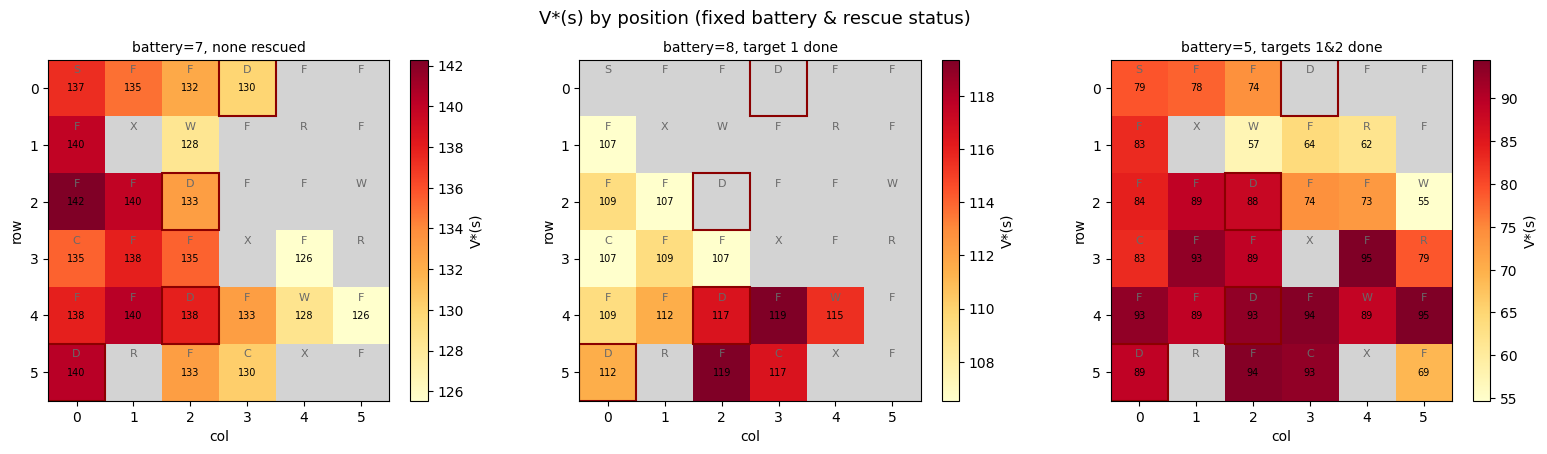

In [44]:
def build_value_slice(V, env, battery, rescued):
    # for fixed battery + rescued status, get V* at each position (max over step counts)
    grid = np.full((env.grid_size, env.grid_size), np.nan)
    for r in range(env.grid_size):
        for c in range(env.grid_size):
            vals = [v for (rr,cc,b,rs,_), v in V.items()
                    if rr==r and cc==c and b==battery and rs==rescued]
            if vals:
                grid[r, c] = max(vals)
    return grid


def plot_value_analysis(env, results):
    # visualize V*(s) across the grid for different fixed battery and rescue conditions
    V = results['V']

    slices = [
        {'battery': 7, 'rescued': (0,0,0), 'title': 'battery=7, none rescued'},
        {'battery': 8, 'rescued': (1,0,0), 'title': 'battery=8, target 1 done'},
        {'battery': 5, 'rescued': (1,1,0), 'title': 'battery=5, targets 1&2 done'},
    ]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    cmap = plt.cm.YlOrRd.copy()
    cmap.set_bad(color='lightgray')

    for ax, sl in zip(axes, slices):
        vg = build_value_slice(V, env, sl['battery'], sl['rescued'])
        im = ax.imshow(vg, origin='upper', cmap=cmap)
        ax.set_title(sl['title'], fontsize=10)
        plt.colorbar(im, ax=ax, fraction=0.046, label='V*(s)')

        for r in range(env.grid_size):
            for c in range(env.grid_size):
                sym = env.initial_grid[r, c]
                if sym == 'D':
                    ax.add_patch(plt.Rectangle((c-0.5,r-0.5), 1, 1,
                                 fill=False, edgecolor='darkred', lw=1.5))
                if not np.isnan(vg[r, c]):
                    ax.text(c, r, f'{vg[r,c]:.0f}', ha='center', va='center', fontsize=7)
                ax.text(c, r-0.32, sym, ha='center', va='center', fontsize=8, color='dimgray')
        ax.set_xticks(range(env.grid_size)); ax.set_yticks(range(env.grid_size))
        ax.set_xlabel('col'); ax.set_ylabel('row')

    plt.suptitle('V*(s) by position (fixed battery & rescue status)', fontsize=13)
    plt.tight_layout()
    plt.show()

plot_value_analysis(env, results)


# observations from the heatmaps
1. High values cluster around unrescued targets, since that's where the +20 reward is.
2. V* drops from slice A to C — fewer targets means less future reward.
3. Danger zones (D) and their neighbours have low values because of the -10 penalty. The policy tries to route around them.
4. Charger cells (C) have good values since recharging lets the drone keep going longer.
5. Wind cells (W) are a bit lower than nearby safe cells since action is 30% random.
6. After a target gets rescued, its cell's value drops since there is no more +20 reward to collect.

## 5. Scalability Discussion

### Curse of Dimensionality

Our 6×6 grid has ~104K reachable states (out of 6×6×11×8×76 = 240768 theoretical max) and runs in under a minute. But, if we change any variable(state/no. of targets/ environment) this problem will not be this simple. 

For example: 
- 10×10 grid: Position space jumps from 36 to 100 cells. With a higher step limit to match, we get over a million states.
- More rescue targets: Each new target doubles the rescued_status combinations (2^k). 5 targets → 32 combos, 8 targets → 256 combos. State count can reach tens of millions.
- Dynamic weather: If wind conditions change over time instead of being fixed per cell, we need to track the weather mode in the state. Even 4 modes = 4× more states. Per-cell dynamic weather makes it completely intractable.

DP would not be sufficient if the Dimensionality increases.

### Why DP becomes difficult

DP needs to list every reachable state, store its value, and sweep through all of them repeatedly until convergence. As the dimensions above grow, the table doesn't fit in memory and each iteration takes too long. This is the curse of dimensionality — DP gives an exact optimal policy, but only when the state space is small enough to list.

### How Deep RL could help

Deep RL replaces the value table with a neural network that approximates V(s) or Q(s,a). This helps because:

- The network generalises across states — no need to visit or store every single one
- It handles continuous states naturally (GPS coordinates, velocity, etc.)
- Training scales with episode count and network size, not state space size

Methods like DQN, PPO, or A2C would work here.

### Relation to real-world autonomous drone systems

In real-world, autonomous drones operate in continuous 3D space with GPS, cameras, variable wind, battery degradation, and moving targets. DP cannot handle such variables. 

In practice, real systems combine classical path planning, learned controllers (Deep RL) for low-level flight control, and hard-coded safety rules like auto-return on low battery are used.
